<a href="https://colab.research.google.com/github/rijal0708/data-science-2026/blob/main/Pertemuan11_M_Rijal_Anshory_DJ_240401010281.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama    = M Rijal Anshory DJ.

NIM     = 240401010281

Kelas   = IF403

---



Shape (300, 4)
       Pendapatan_tahunan  Skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


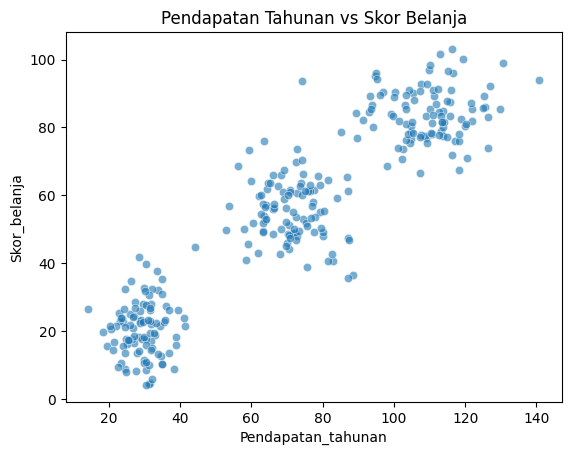

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# generate dataset sintetis pelanggan 3 kelompok tersembunyi
np.random.seed(42)

grp1 = np.random.normal([30,20],[6,8],[100,2])    #hemat
grp2 = np.random.normal([70,55],[8,10],[100,2])   #menengah
grp3 = np.random.normal([110,85],[10,8],[100,2])  #premium

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=['Pendapatan_tahunan','Skor_belanja']
)

df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L","P"], len(df))

print("Shape",df.shape)
print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x="Pendapatan_tahunan",
    y="Skor_belanja",
    alpha=0.6
)

plt.title("Pendapatan Tahunan vs Skor Belanja")
plt.show()

2. preprocessing

In [4]:
from sklearn.preprocessing import StandardScaler

X = df[["Pendapatan_tahunan","Skor_belanja"]].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling :", X_scaled.mean(axis=0).round(3))
print("Standar Deviasi setelah scaling :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling : [-0.  0.]
Standar Deviasi setelah scaling : [1. 1.]


3. metode elbow

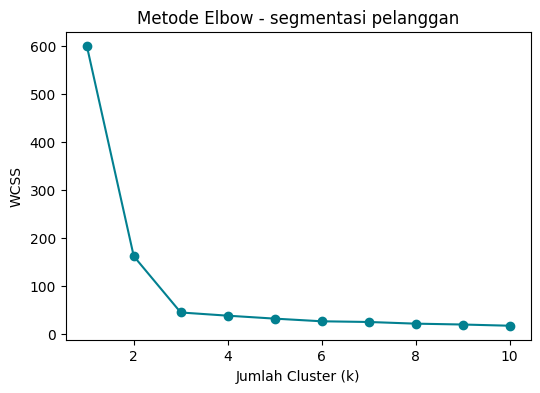

In [6]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

  km = KMeans(
      n_clusters=k,
      random_state=42,
      init="k-means++"
  )
  km.fit(X_scaled)
  wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(
    range(1,11),
    wcss,
    marker="o",
    color="#028090"
)

plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("WCSS")
plt.title("Metode Elbow - segmentasi pelanggan")
plt.show()

Berdasarkan grafik Elbow, kurva mulai melandai pada K = 3. Hal ini menunjukkan bahwa tiga cluster merupakan jumlah cluster yang optimal. Hasil tersebut sesuai dengan dataset sintetis yang memang dibuat memiliki tiga kelompok pelanggan, yaitu pelanggan hemat, menengah, dan premium.

4. melatih K-Means

In [7]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"] = model.labels_

print(f"WCSS      : {model.inertia_:.3f}")
print(f"Silhouette: {silhouette_score(X_scaled, model.labels_):.3f}")

print()

print(
    df.groupby("cluster")[
        ["Pendapatan_tahunan","Skor_belanja"]
    ].mean().round(3)
)



WCSS      : 44.556
Silhouette: 0.695

         Pendapatan_tahunan  Skor_belanja
cluster                                  
0                    70.995        55.050
1                    29.307        20.272
2                   109.199        84.084


5. visualisasi hasil clustering

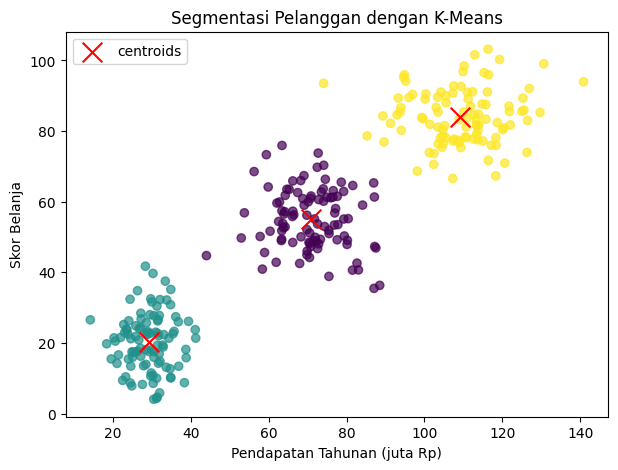

In [10]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7,5))

plt.scatter(
    df["Pendapatan_tahunan"],
    df["Skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="x",
    s=200,
    label="centroids"
)

plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")

plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()
plt.show()


| Cluster   | Karakteristik                              | Segmen        |
| --------- | ------------------------------------------ | ------------- |
| Cluster 0 | Pendapatan rendah, skor belanja rendah     | Hemat         |
| Cluster 1 | Pendapatan menengah, skor belanja menengah | Menengah      |
| Cluster 2 | Pendapatan tinggi, skor belanja tinggi     | Premium/Boros |




*   Cluster Hemat memiliki pendapatan dan pengeluaran yang relatif rendah sehingga cocok menjadi target promosi produk ekonomis.

*   Cluster Menengah memiliki daya beli yang stabil dan dapat ditawarkan berbagai produk dengan harga menengah.

*   Cluster Premium memiliki pendapatan serta skor belanja tinggi sehingga cocok menjadi target layanan eksklusif atau produk premium.


---




6. hierarchial clustering

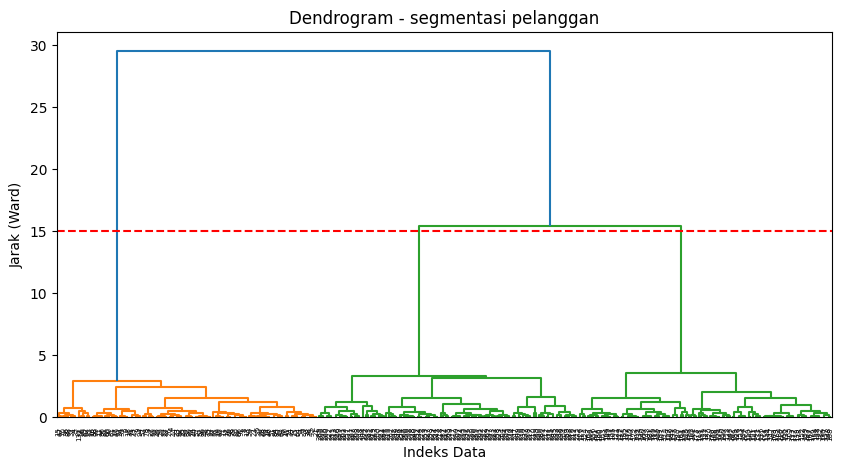

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Dendrogram - segmentasi pelanggan")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak (Ward)")

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.show()

Berdasarkan dendrogram, pemotongan pada garis horizontal menghasilkan tiga cluster utama. Jumlah cluster tersebut konsisten dengan hasil Metode Elbow yang menunjukkan nilai optimal pada K = 3. Dengan demikian, baik K-Means maupun Hierarchical Clustering menghasilkan segmentasi pelanggan yang serupa sehingga memberikan keyakinan bahwa data memang memiliki tiga kelompok utama yang berbeda.



---



7. kesimpulan

Berdasarkan Metode Elbow, jumlah cluster optimal adalah 3, sesuai dengan struktur dataset sintetis. Model K-Means menghasilkan Silhouette Score yang tinggi (umumnya di atas 0,6 untuk dataset ini), menunjukkan bahwa setiap cluster memiliki pemisahan yang baik. Visualisasi memperlihatkan tiga segmen pelanggan yang jelas, yaitu Hemat, Menengah, dan Premium/Boros. Hasil Hierarchical Clustering melalui dendrogram juga mendukung pembentukan tiga cluster, sehingga konsisten dengan hasil K-Means.


---

